In [3]:
import sys

# Checking if colab or local
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    path = '/content/drive/MyDrive/Grokking Machine Learning/Bootcamp Materials/04- Python Deep Learning/W21/P1_Sentiment Analysis/tweets.csv'
else:
    path = 'tweets.csv'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Description

**This is the sentiment140 dataset. It contains 1,600,000 tweets extracted using the Twitter API. The tweets have been annotated (0 = negative, 2 = neutral, 4 = positive) and they can be used to detect sentiment. It contains the following 6 fields:**

- `target`: the polarity of the tweet (0 = negative, 2 = neutral, 4 = positive)
- `ids`: The ID of the tweet (2087)
- `date`: the date of the tweet (Sat May 16 23:58:44 UTC 2009)
- `flag`: The query (lyx). If there is no query, then this value is NO_QUERY.
- `user`: the user that tweeted (robotickilldozr)
- `text`: the text of the tweet (Lyx is cool)

According to the creators of the dataset:

"Our approach was unique because our training data was automatically created, as opposed to having humans manually annotate tweets. In our approach, we assume that any tweet with positive emoticons, like :), was positive, and tweets with negative emoticons, like :(, were negative. We used the Twitter Search API to collect these tweets by using keyword search."


# Read Dataset

In [4]:
import pandas as pd

data = pd.read_csv(path, encoding = "ISO-8859-1", header=None)
data.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
data.columns = ['target', 'id', 'date', 'flag', 'user', 'text']
data.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [6]:
df = data[['target', 'text']]
df.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [7]:
df.target.value_counts()

0    800000
4    800000
Name: target, dtype: int64

In [8]:
df.loc[:, 'target'] = df.target.replace(4, 1)
df.target.value_counts()

<ipython-input-8-03d9a32852bf>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'target'] = df.target.replace(4, 1)


0    800000
1    800000
Name: target, dtype: int64

In [9]:
from wordcloud import WordCloud

data_neg = df[df.target == 0].text
data_pos = df[df.target == 1].text

neg_wordcloud = WordCloud(max_words= 1000,  background_color='white', width=512, height=384).generate(" ".join(data_neg))
pos_wordcloud = WordCloud(max_words= 1000,  background_color='white',width=512, height=384).generate(" ".join(data_pos))

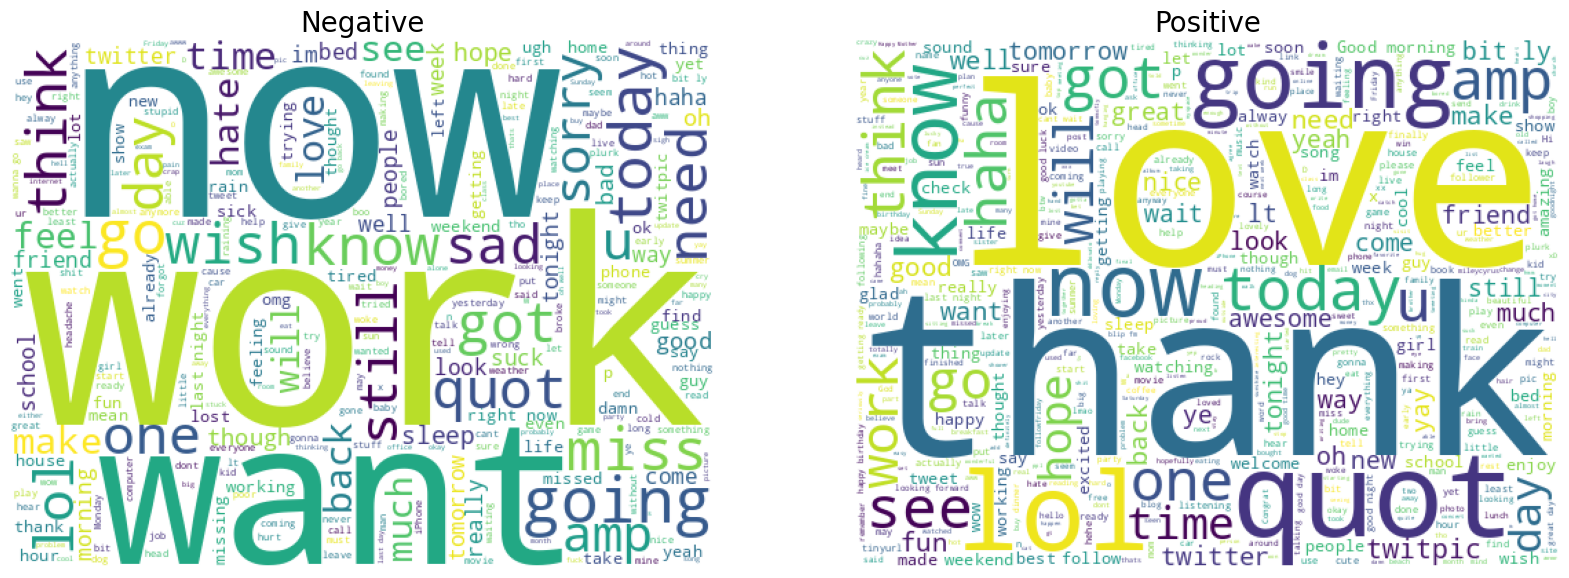

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=[20, 8])

# wordclouds
ax[0].imshow(neg_wordcloud)
ax[0].axis('off')
ax[0].set_title('Negative', fontsize=20)

ax[1].imshow(pos_wordcloud)
ax[1].axis('off')
ax[1].set_title('Positive', fontsize=20)

plt.show()

# Text Preprocessing

In [11]:
import nltk
nltk.download('stopwords', quiet=True)

True

In [12]:
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
import re

to_remove = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"
stopwords_ = stopwords.words('english')
stemmer = SnowballStemmer("english")

def preprocess_text(text, stem=False):
    # Remove link,user and special characters
    text = re.sub(to_remove, ' ', text.lower()).strip()
    tokens = text.split()
    # Remove stop words
    tokens = [token for token in tokens if token not in stopwords_]
    # Stemming the tokens
    if stem:
        tokens = [stemmer.stem(token) for token in tokens]
    return " ".join(tokens)

In [13]:
df.text[10]

"spring break in plain city... it's snowing "

In [14]:
preprocess_text(df.text[10])

'spring break plain city snowing'

In [15]:
preprocess_text(df.text[10], stem=True)

'spring break plain citi snow'

In [16]:
%%time
df['processed_text'] = df.text.apply(lambda x: preprocess_text(x, stem=True))

CPU times: user 3min 10s, sys: 361 ms, total: 3min 10s
Wall time: 3min 12s


<timed exec>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [17]:
df.head()

,target,text,processed_text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda got david carr third day
1,0,is upset that he can't update his Facebook by ...,upset updat facebook text might cri result sch...
2,0,@Kenichan I dived many times for the ball. Man...,dive mani time ball manag save 50 rest go bound
3,0,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire
4,0,"@nationwideclass no, it's not behaving at all....",behav mad see


# Split data

In [18]:
X = df.processed_text
y = df.target

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1280000,) (320000,) (1280000,) (320000,)


In [20]:
X_train.head()

1374558    ya quot like palm pre touchston charger readyn...
1389115                felt earthquak afternoon seem epicent
1137831                               ruffl shirt like likey
790714     pretti bad night crappi morn fml buttfac didnt...
1117911                                      yeah clear view
Name: processed_text, dtype: object

# Feature Extraction

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train_prep = vectorizer.fit_transform(X_train)
X_test_prep = vectorizer.transform(X_test)

# Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_prep, y_train)

print('Train score: ', log_reg.score(X_train_prep, y_train))
print('Test score: ', log_reg.score(X_test_prep, y_test))

Train score:  0.79489140625
Test score:  0.77498125


Classification report:
              precision    recall  f1-score   support

           0       0.78      0.76      0.77    159494
           1       0.77      0.79      0.78    160506

    accuracy                           0.77    320000
   macro avg       0.78      0.77      0.77    320000
weighted avg       0.78      0.77      0.77    320000

Confusion matrix:


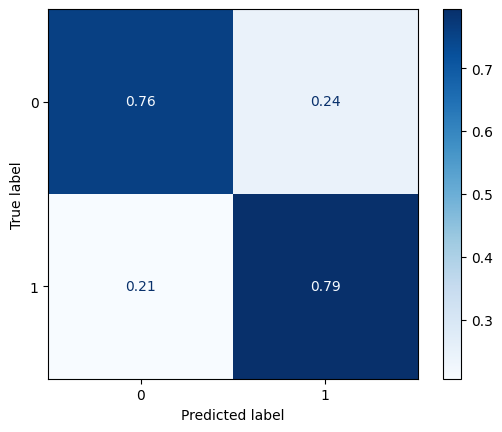

In [23]:
# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

y_pred = log_reg.predict(X_test_prep)

print('Classification report:')
print(classification_report(y_test, y_pred))

print('Confusion matrix:')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', normalize='true');